Tratamento e Visualização dos Dados - Raman
===

**Autor:** [Mateus de Jesus Mendes](mailto:mateus25032@ilum.cnpem.br)

##### **Funções**

Importação de bibliotecas:

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.signal import savgol_filter
from scipy.integrate import trapezoid

Plot singular:

In [168]:
def raman_plot(file_path=None, sample_name=None):
    """
    Gera plots (Matplotlib e Plotly) de um único espectro Raman.

    ### Parâmetros
    - file_path (str): Caminho do arquivo contendo dados de espectroscopia Raman.
    - sample_number (object): Nome da amostra.
    """
    
    # Leitura das linhas do arquivo
    data_raman = []
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2:
                try:
                    x, y = map(float, parts[:2])
                    data_raman.append((x, y))
                except:
                    continue

    df_raman = pd.DataFrame(data_raman, columns=['Wavenumber', 'Intensity'])

    # Matplotlib
    plt.figure(figsize=(6.3, 4.2), dpi=300)
    plt.plot(df_raman['Wavenumber'], df_raman['Intensity'], linewidth=1)
    plt.xlabel('Número de Ondas')
    plt.ylabel('Intensidade (u.a.)')
    plt.title(f'Espectro Raman — {sample_name}')
    plt.show()

    # Plotly
    fig_raman = go.Figure()

    fig_raman.add_trace(go.Scatter(
        x=df_raman['Wavenumber'],
        y=df_raman['Intensity'],
        mode='lines',
        line=dict(width=1),
        name='Raman'
    ))

    fig_raman.update_layout(
        title=f'Espectro Raman — {sample_name}',
        xaxis=dict(title='Número de Ondas'),
        yaxis=dict(title='Intensidade (u.a.)'),
        template='simple_white',
        width=800,
        height=500
    )

    fig_raman.show()

Plot conjunto (*overlayed*):

In [ ]:
def raman_overlay(file_paths, sample_names=None):
    """
    Gera plots (Matplotlib e Plotly) de múltiplos espectros Raman em overlay.

    ### Parâmetros

    - file_paths (list of str): Lista de caminhos dos arquivos contendo dados de espectroscopia Raman.
    - sample_names (list of str, optional): Nomes das amostras.
    """

    # Se não passar sample_name, usa nome do arquivo
    if sample_names is None:
        sample_names = [fp.split('/')[-1] for fp in file_paths]

    # Matplotlib
    plt.figure(figsize=(6.3, 4.2), dpi=300)
    
    for fp, label in zip(file_paths, sample_names):
        data_raman = []
        with open(fp, 'r') as f:
            for line in f:
                if line.startswith('##') or line.strip() == '':
                    continue
                parts = line.strip().split()
                if len(parts) >= 2:
                    try:
                        x, y = map(float, parts[:2])
                        data_raman.append((x, y))
                    except:
                        continue

        df_raman = pd.DataFrame(data_raman, columns=['Wavenumber', 'Intensity'])
        plt.plot(df_raman['Wavenumber'], df_raman['Intensity'], linewidth=1, label=label)

    plt.xlabel('Número de Ondas')
    plt.ylabel('Intensidade (u.a.)')
    plt.title('Overlay dos Espectros Raman')
    plt.legend()
    plt.show()

    # Plotly
    fig_raman = go.Figure()

    for fp, label in zip(file_paths, sample_names):
        data_raman = []
        with open(fp, 'r') as f:
            for line in f:
                if line.startswith('##') or line.strip() == '':
                    continue
                parts = line.strip().split()
                if len(parts) >= 2:
                    try:
                        x, y = map(float, parts[:2])
                        data_raman.append((x, y))
                    except:
                        continue

        df_raman = pd.DataFrame(data_raman, columns=['Wavenumber', 'Intensity'])
        fig_raman.add_trace(go.Scatter(
            x=df_raman['Wavenumber'],
            y=df_raman['Intensity'],
            mode='lines',
            line=dict(width=1),
            name=label
        ))

    fig_raman.update_layout(
        title='Overlay de Espectros Raman',
        xaxis=dict(title='Número de Ondas'),
        yaxis=dict(title='Intensidade (u.a.)'),
        template='simple_white',
        width=800,
        height=500
    )

    fig_raman.show()

Cálculo do *baseline*:

In [170]:
def baseline_als(file_path, lam=1e5, p=0.01, n_iter=10):
    """
    Correção baseline via Mínimos Quadrados Assimétricos.

    ### Parâmetros
    - lam (float) : Parâmetro de homogeneidade
    - p (float) : Parâmetro de assimetria (p ~ 0.001-0.1 for Raman)
    - n_iter (int) : Número de iterações

    ### Retorna
    Tupla contendo a correção baseline dos dados.
    """

    data_raman = []
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2:
                try:
                    x, y = map(float, parts[:2])
                    data_raman.append((x, y))
                except:
                    continue

    df_raman = pd.DataFrame(data_raman, columns=['Wavenumber', 'Intensity'])
    x = df_raman['Wavenumber']
    y = df_raman['Intensity']
    
    L = len(y)
    # Second-difference Matrix
    D = sparse.diags([1, -2, 1], [0, -1, -2], shape=(L, L))
    D = D.T @ D
    w = np.ones(L)
    for i in range(n_iter):
        W = sparse.diags(w, 0)
        Z = W + lam * D
        z = spsolve(Z, w * y)
        w = p * (y > z) + (1 - p) * (y <= z)

    return x, y, z

# Raman - GO

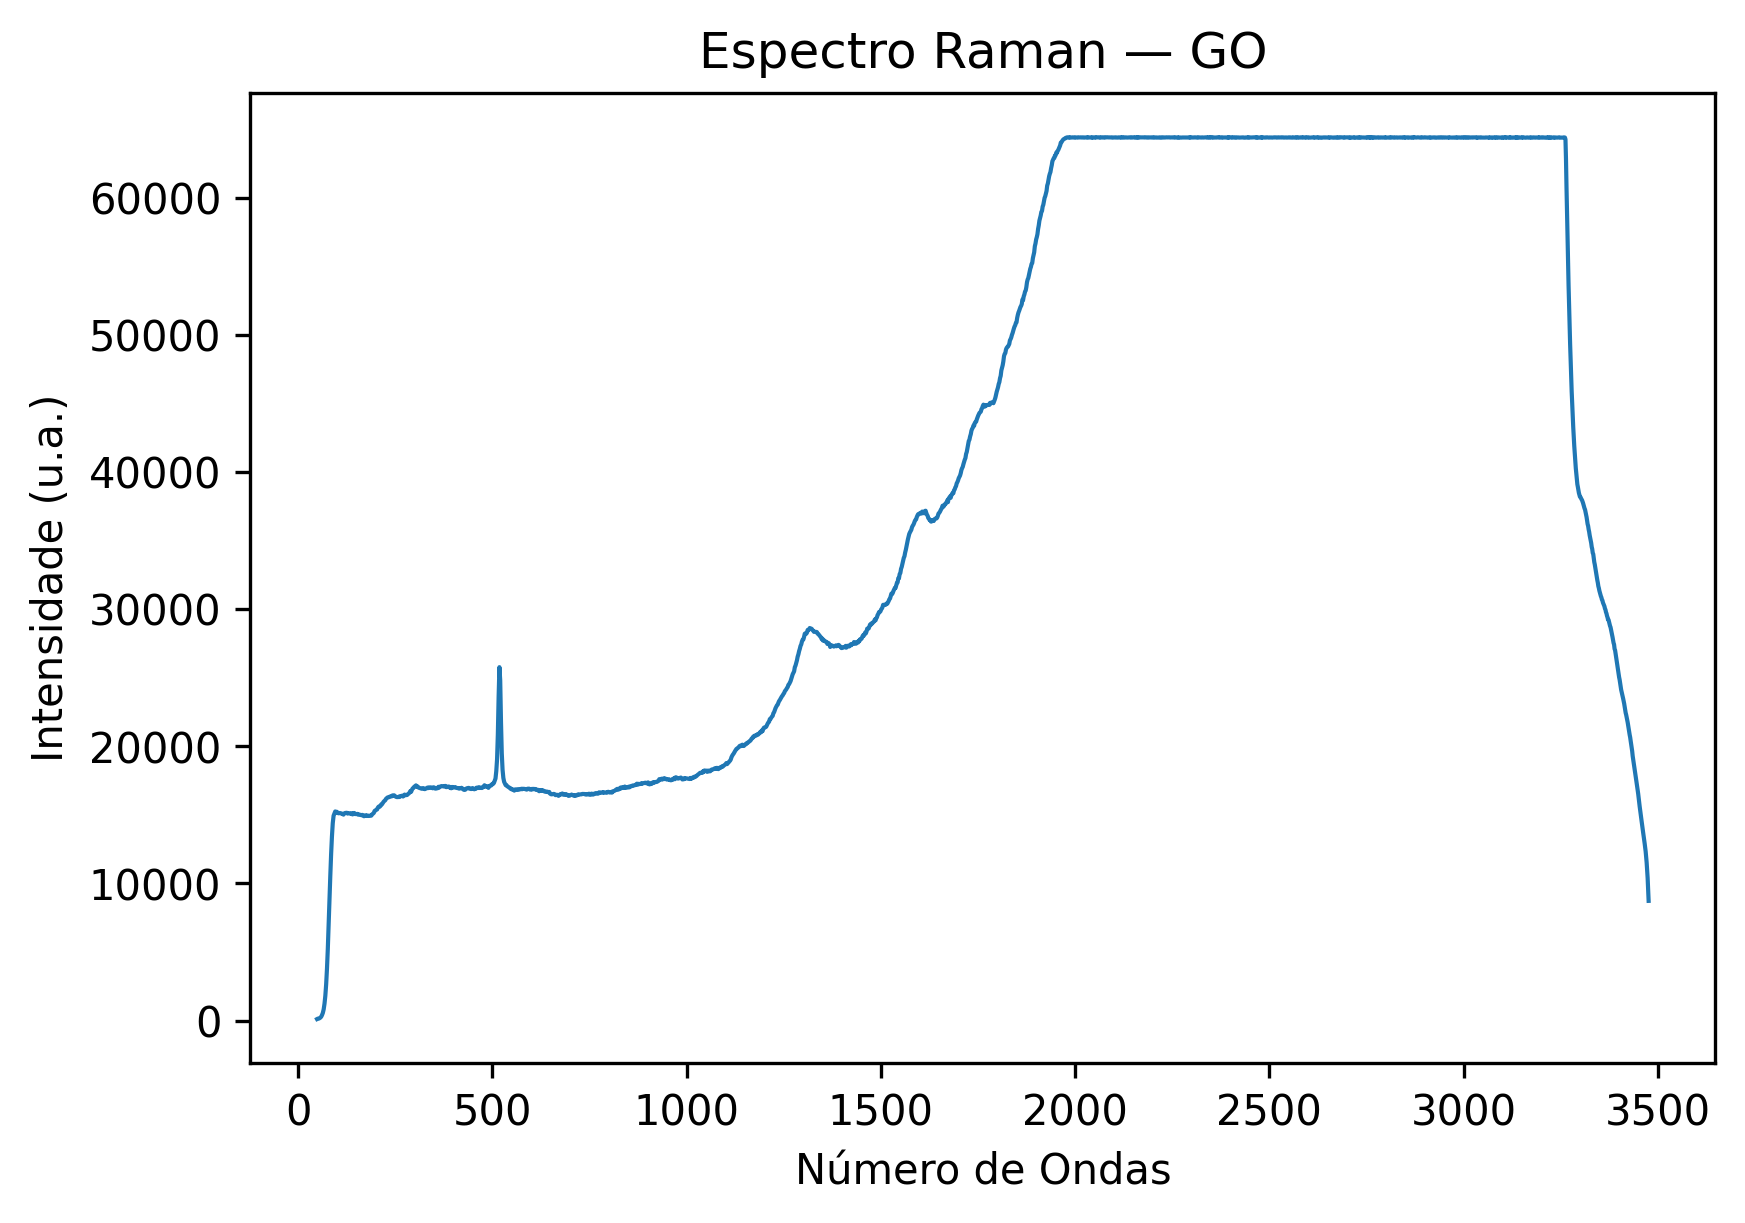

In [171]:
raman_plot('GO_MMV.txt', 'GO')

# Raman - rGO

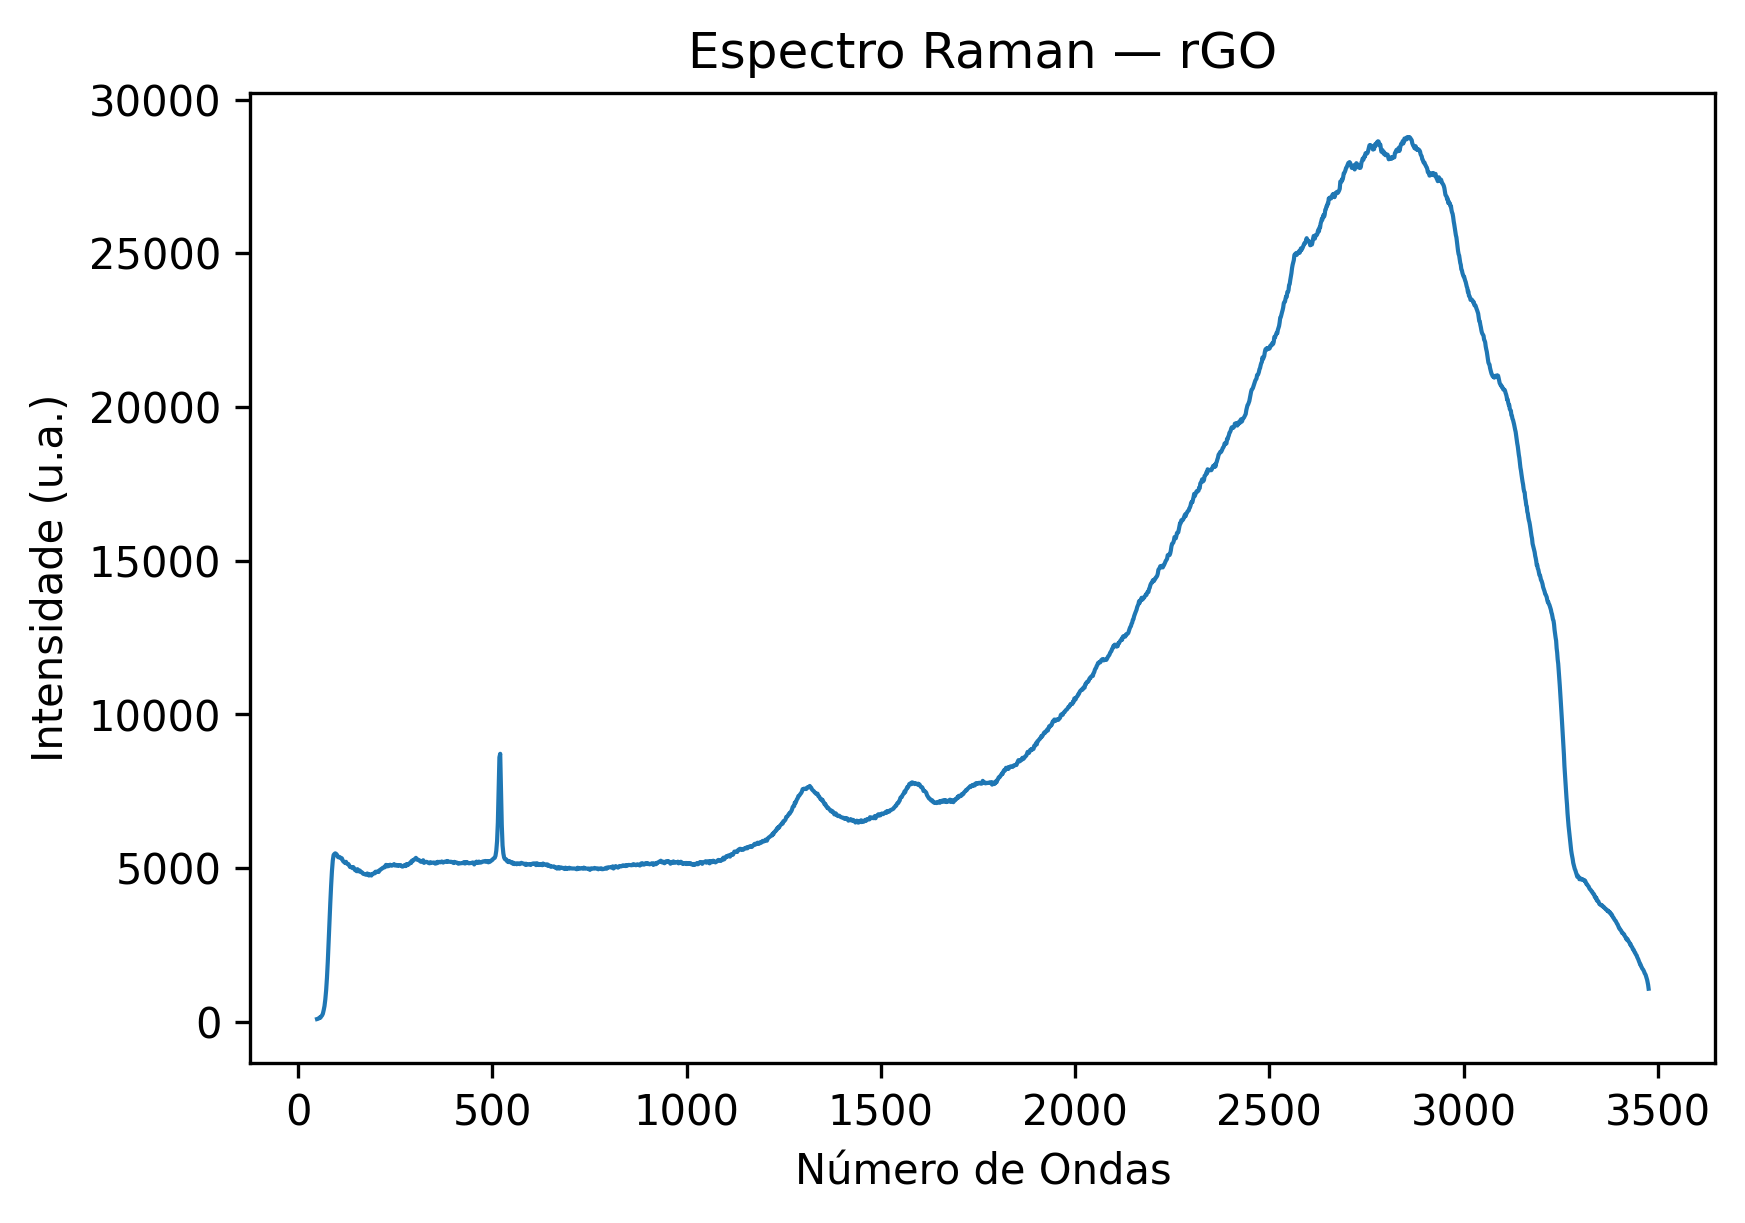

In [172]:
raman_plot('rGO_MMV.txt', 'rGO')

# *Overlay*

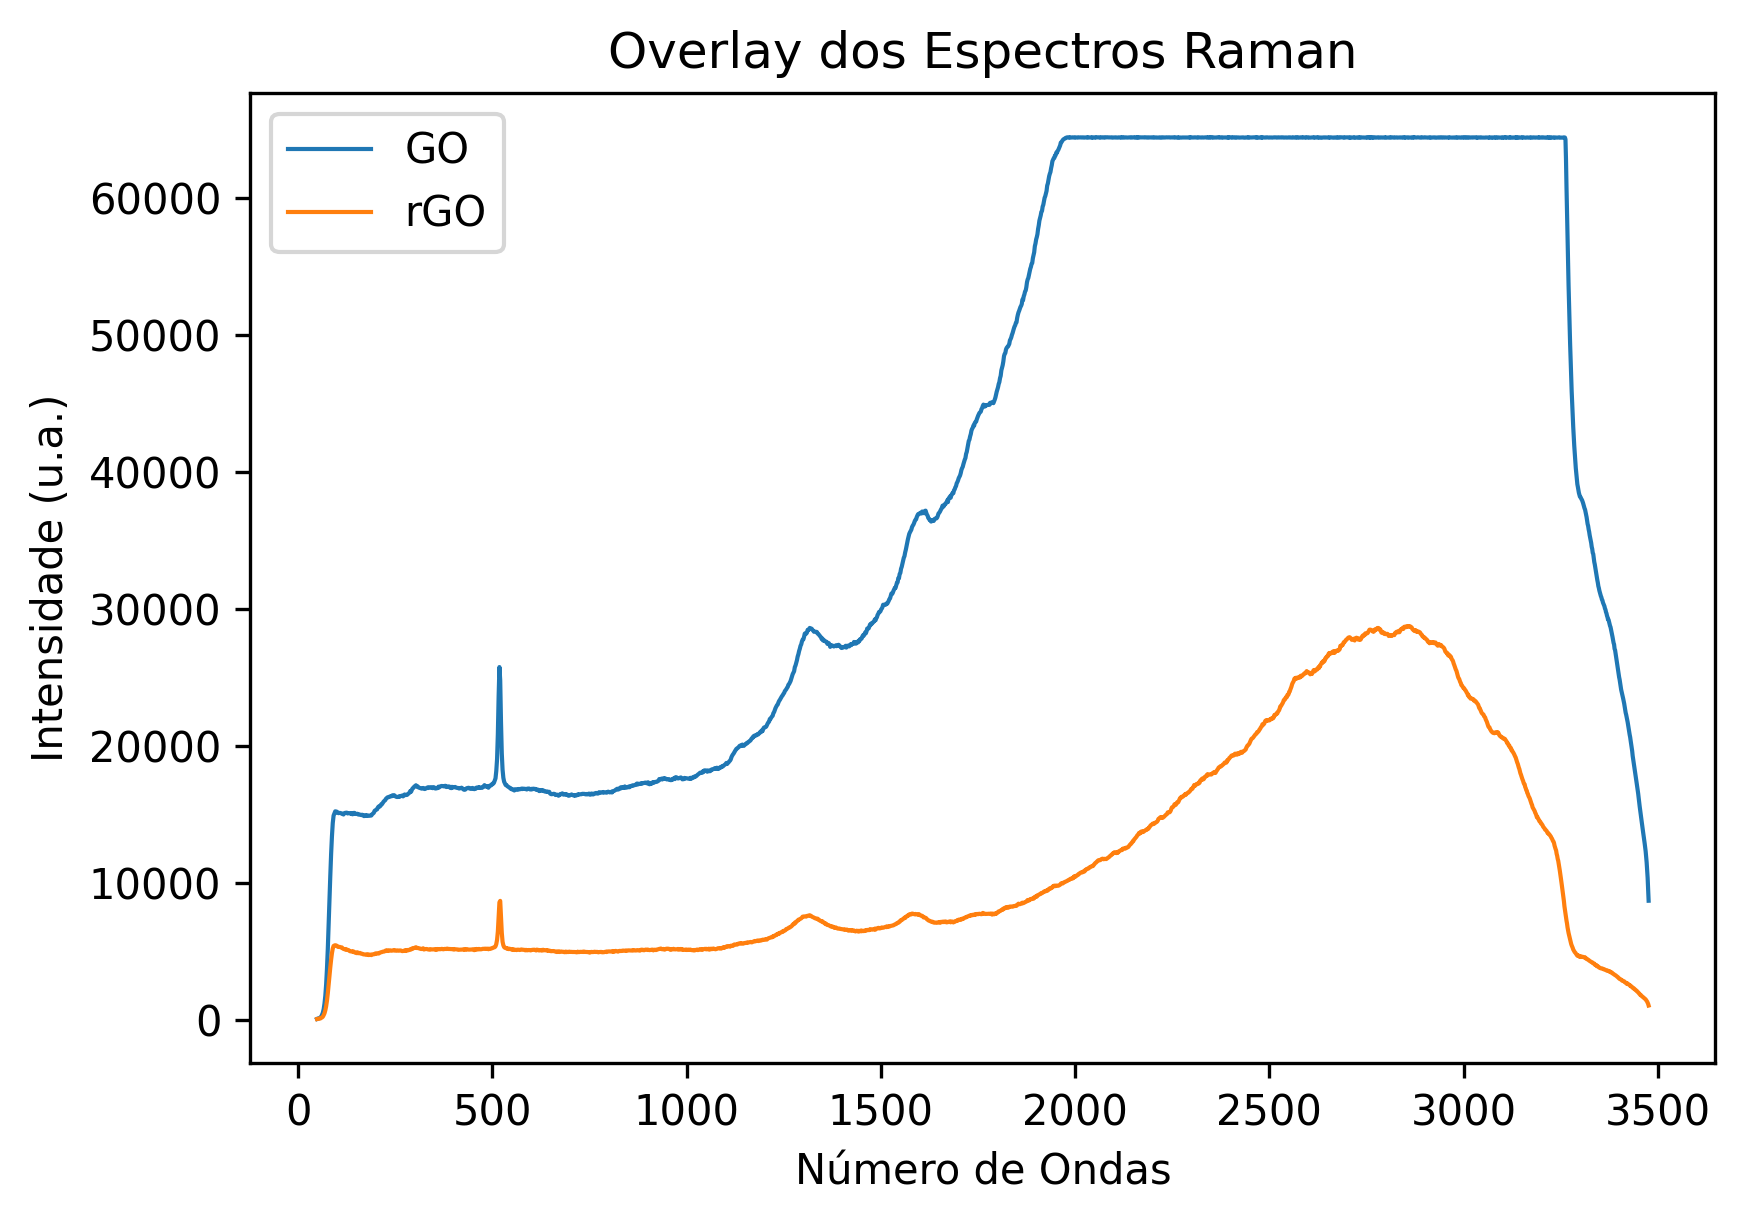

In [ ]:
raman_overlay(file_paths=('GO_MMV.txt', 'rGO_MMV.txt'), sample_names=('GO', 'rGO'))

# *Baseline* - GO

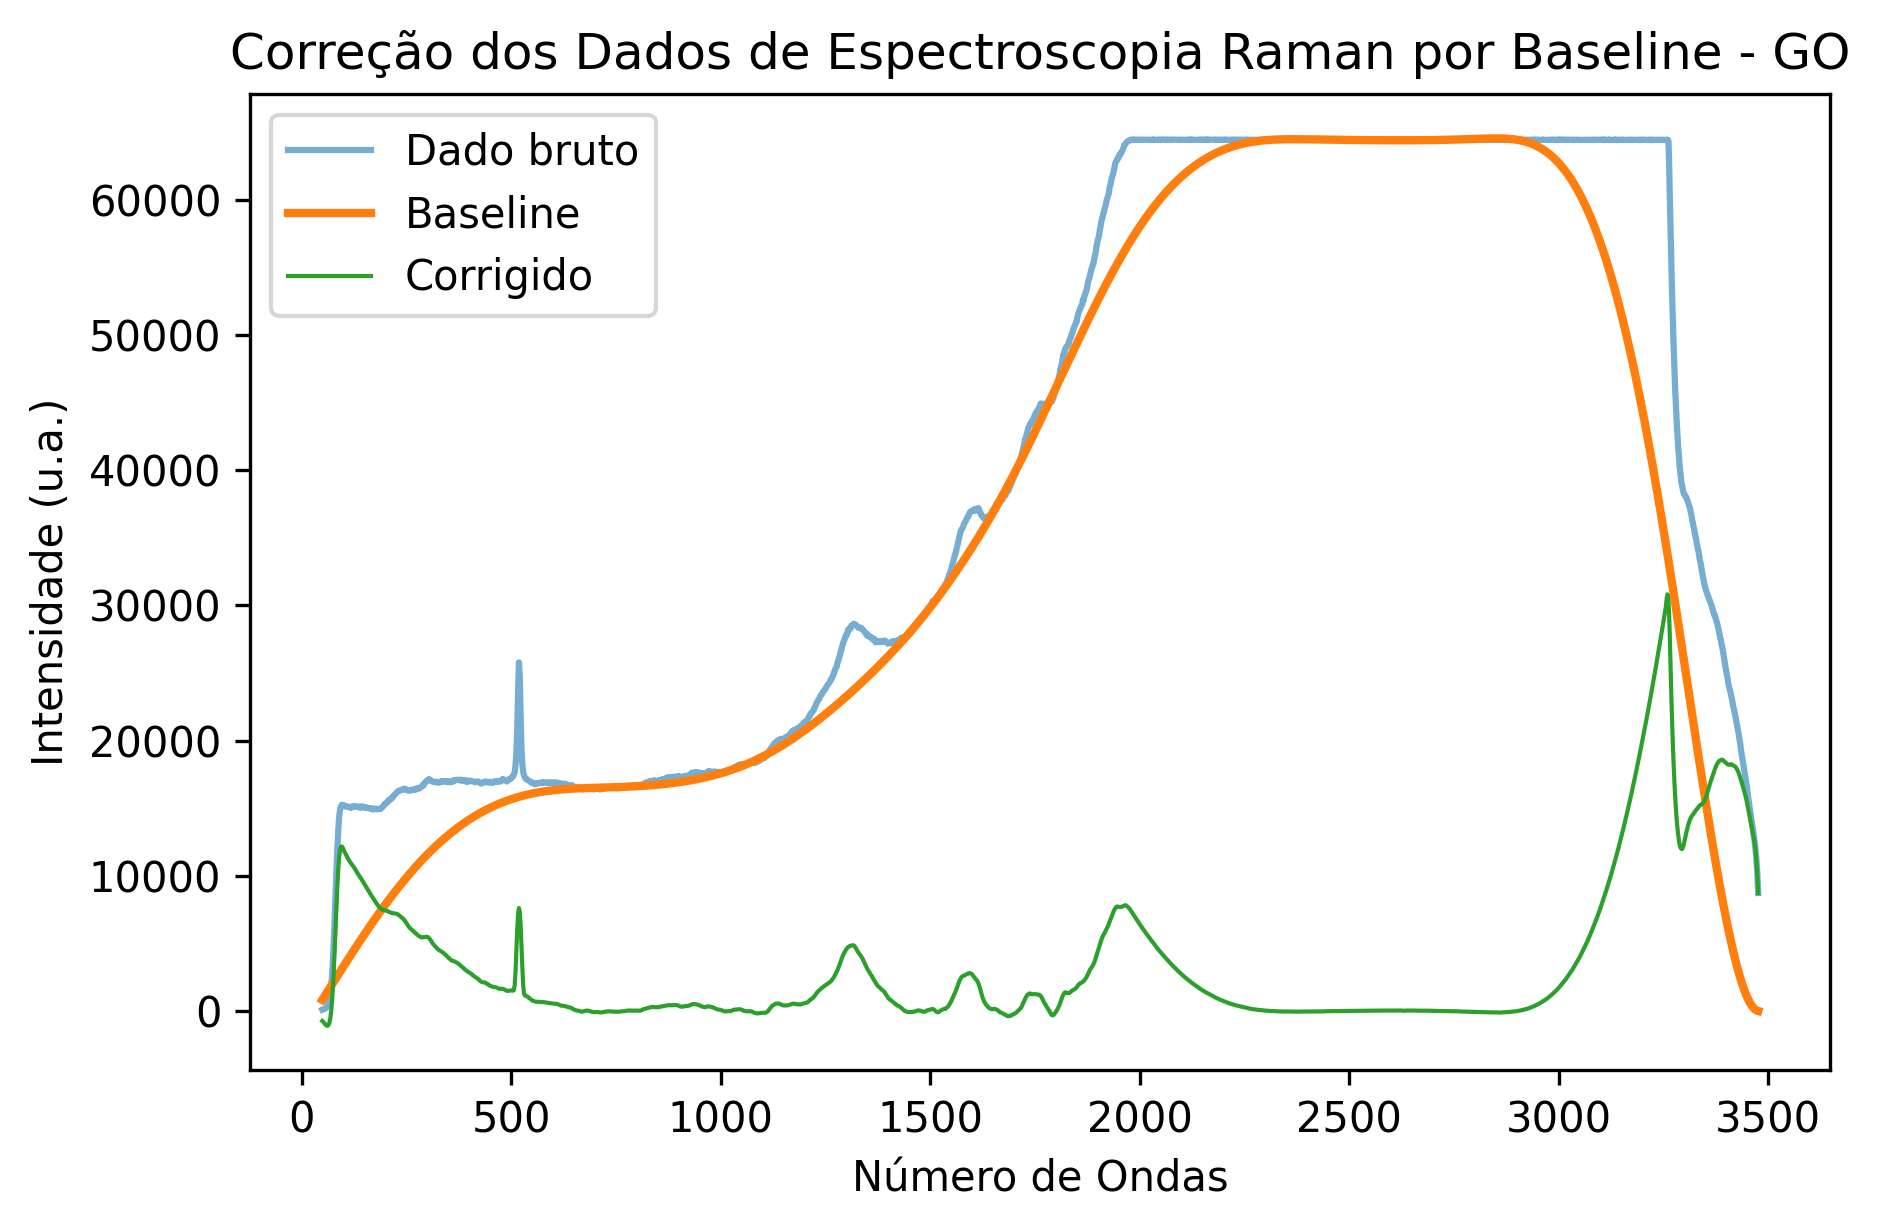

In [174]:
x, y, baseline = baseline_als('GO_MMV.txt', lam=1e6, p=0.01, n_iter=10)
y_smooth = savgol_filter(y, window_length=11, polyorder=3)
y_corr = y_smooth - baseline

# Matplotlib
plt.figure(figsize=(6.3, 4.2), dpi=300)
plt.plot(x, y, label='Dado bruto', alpha=0.6)
plt.plot(x, baseline, label='Baseline', linewidth=2)
plt.plot(x, y_corr, label='Corrigido', linewidth=1)
plt.title('Correção dos Dados de Espectroscopia Raman por Baseline - GO')
plt.legend()
plt.xlabel('Número de Ondas')
plt.ylabel('Intensidade (u.a.)')
plt.tight_layout()
plt.show()

# Plotly
fig = go.Figure()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=x, y=y,
    mode='lines',
    name='Dado bruto',
    opacity=0.6,
    line=dict(color='#1f77b4')
))

fig.add_trace(go.Scatter(
    x=x, y=baseline,
    mode='lines',
    name='Baseline',
    line=dict(color='#ff7f0e', width=2)
))

fig.add_trace(go.Scatter(
    x=x, y=y_corr,
    mode='lines',
    name='Corrigido',
    line=dict(color='#2ca02c', width=1)
))

fig.update_layout(
    title='Correção dos Dados de Espectroscopia Raman por Baseline - GO',
    xaxis_title='Número de Ondas',
    yaxis_title='Intensidade (u.a.)',
    template='plotly_white',
    width=800,
    height=400,
    legend=dict(
        title='',
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='right',
        x=1
    )
)

fig.show()

Área sob o pico D:

In [175]:
xmin, xmax = 1119.31, 1436.31 # Limites definidos para o pico D
mask = (x >= xmin) & (x <= xmax)
area_D_GO = -trapezoid(y_corr[mask], x[mask])    # y_corr = y_baseline_subtraído
print(f'Área sob o pico D (GO): {area_D_GO} (u.a.)')

Área sob o pico D (GO): 580976.3720730366 (u.a.)


Área sob o pico G:

In [176]:
xmin, xmax = 1525.43, 1660.53 # Limites definidos para o pico G
mask = (x >= xmin) & (x <= xmax)
area_G_GO = -trapezoid(y_corr[mask], x[mask])    # y_corr = y_baseline_subtraído
print(f'Área sob o pico G (GO): {area_G_GO} (u.a.)')

Área sob o pico G (GO): 177844.09437567703 (u.a.)


Razão entre as áreas ($\mathrm{\frac{A_D}{A_G}}$):

In [177]:
DG_ratio = area_D_GO / area_G_GO
print(f'Razão D/G (GO): {DG_ratio}')

Razão D/G (GO): 3.2667734855776818


# *Baseline* - rGO

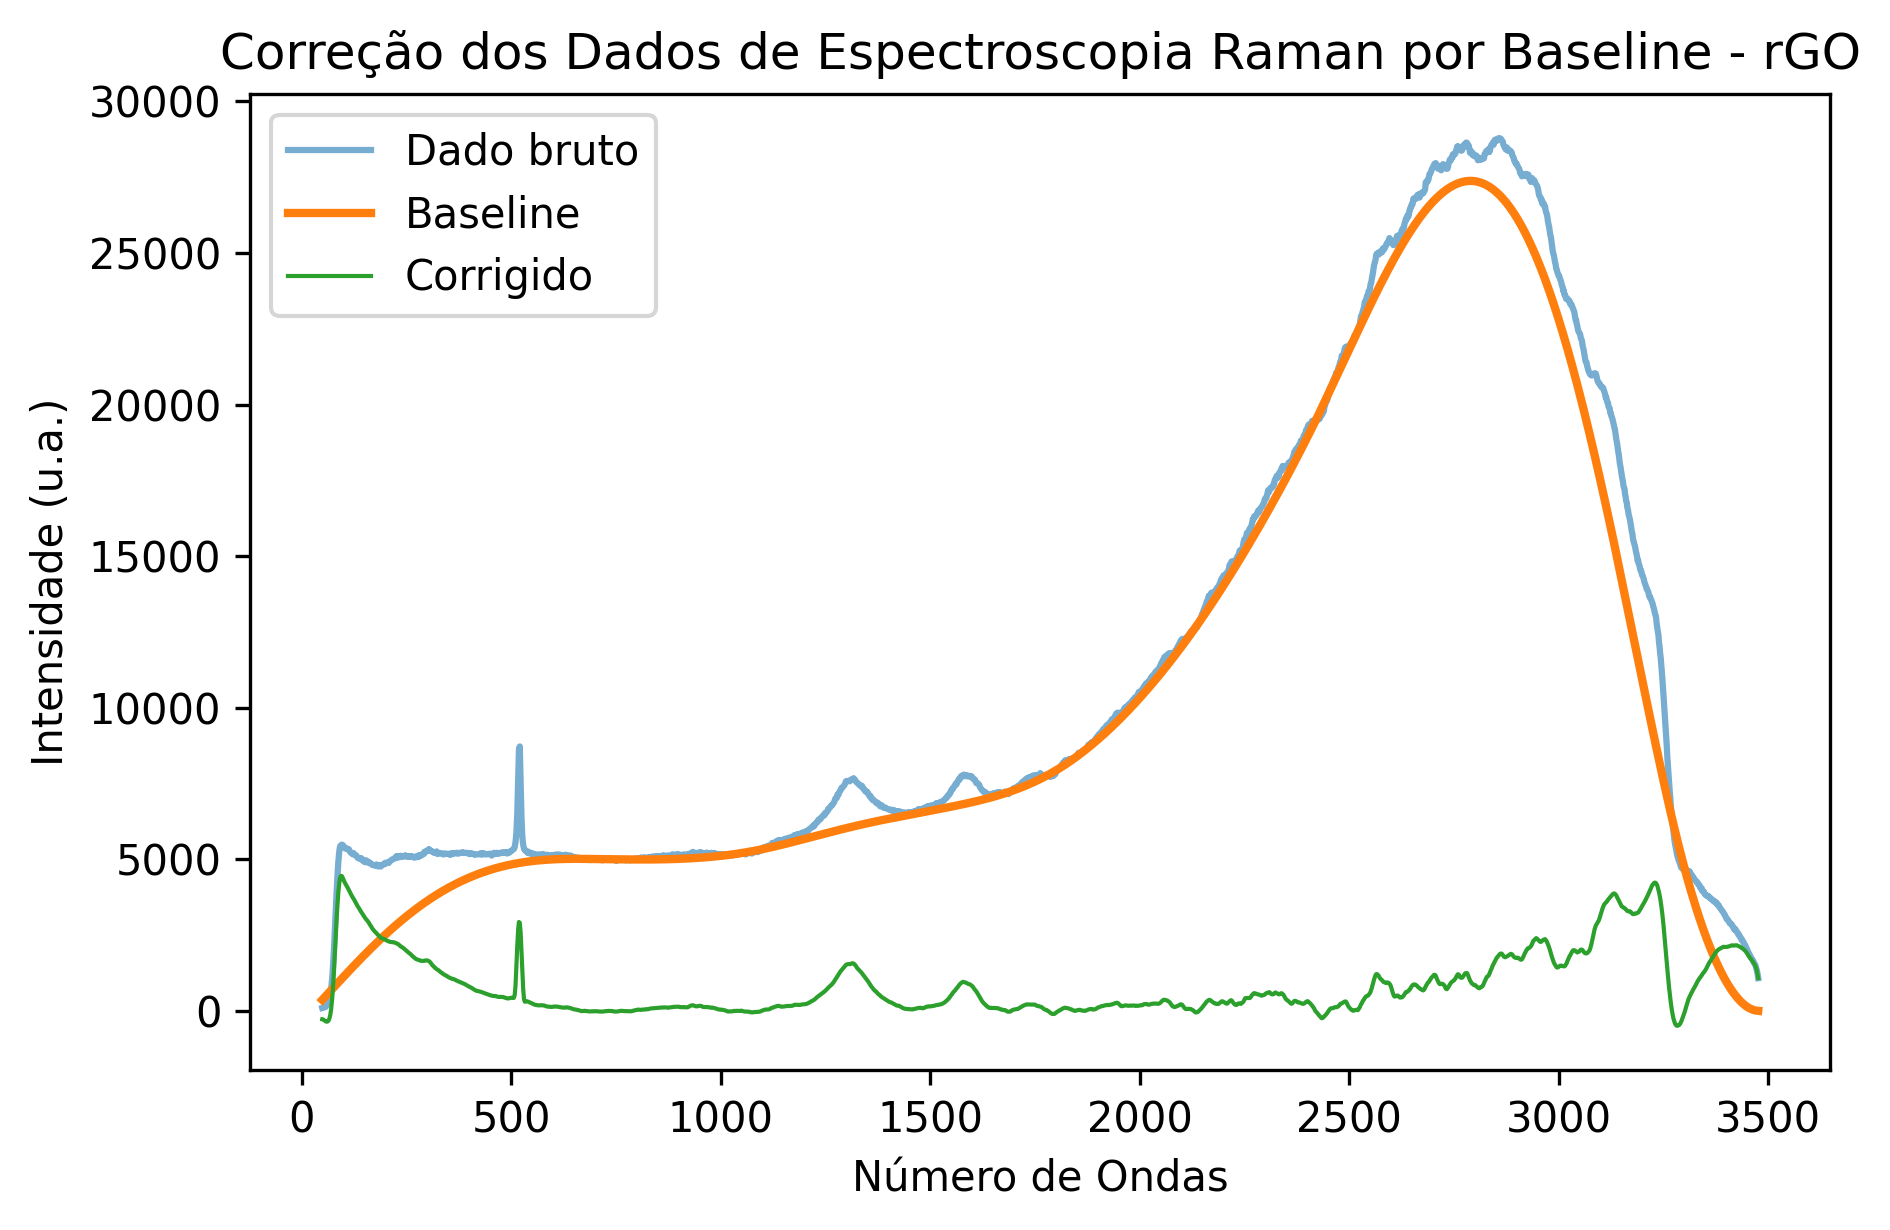

In [178]:
x, y, baseline = baseline_als('rGO_MMV.txt', lam=1e6, p=0.01, n_iter=10)
y_smooth = savgol_filter(y, window_length=11, polyorder=3)
y_corr = y_smooth - baseline

# Matplotlib
plt.figure(figsize=(6.3, 4.2), dpi=300)
plt.plot(x, y, label='Dado bruto', alpha=0.6)
plt.plot(x, baseline, label='Baseline', linewidth=2)
plt.plot(x, y_corr, label='Corrigido', linewidth=1)
plt.title('Correção dos Dados de Espectroscopia Raman por Baseline - rGO')
plt.legend()
plt.xlabel('Número de Ondas')
plt.ylabel('Intensidade (u.a.)')
plt.tight_layout()
plt.show()

# Plotly
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=x, y=y,
    mode='lines',
    name='Dado bruto',
    opacity=0.6,
    line=dict(color='#1f77b4')
))

fig.add_trace(go.Scatter(
    x=x, y=baseline,
    mode='lines',
    name='Baseline',
    line=dict(color='#ff7f0e', width=2)
))

fig.add_trace(go.Scatter(
    x=x, y=y_corr,
    mode='lines',
    name='Corrigido',
    line=dict(color='#2ca02c', width=1)
))

fig.update_layout(
    title='Correção dos Dados de Espectroscopia Raman por Baseline - rGO',
    xaxis_title='Número de Ondas',
    yaxis_title='Intensidade (u.a.)',
    template='plotly_white',
    width=800,
    height=400,
    legend=dict(
        title='',
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='right',
        x=1
    )
)

fig.show()

Área sob o pico D:

In [179]:
xmin, xmax = 1111.82, 1441.68 # Limites definidos para o pico D
mask = (x >= xmin) & (x <= xmax)
area_D = -trapezoid(y_corr[mask], x[mask])    # y_corr = y_baseline_subtraído
print(f'Área sob o pico D (rGO): {area_D} (u.a.)')

Área sob o pico D (rGO): 194707.5401124893 (u.a.)


Área sob o pico G:

In [180]:
xmin, xmax = 1463.16, 1677.89 # Limites definidos para o pico G
mask = (x >= xmin) & (x <= xmax)
area_G = -trapezoid(y_corr[mask], x[mask]) # y_corr = y_baseline_subtraído
print(f'Área sob o pico G (rGO): {area_G} (u.a.)')

Área sob o pico G (rGO): 77710.4680448808 (u.a.)


Razão entre as áreas ($\mathrm{\frac{A_D}{A_G}}$):

In [181]:
DG_ratio = area_D / area_G
print(f'Razão D/G (rGO): {DG_ratio}')

Razão D/G (rGO): 2.50555098960462
